# Coupling Analysis — Reference + Methods + Dynamics

Change the knobs at the top (especially **`PITCH_TRANSFORM`**) and
*Run All* to sweep the full pipeline end-to-end:

1. **Section 1** — Load reference + method feature parquets, compute F0
   derivatives with the chosen pitch transform.
2. **Section 2 (exp1)** — Fit reference coupling models
   ($d_i = \beta_0 + \beta_1 p + \beta_2 p^2 + \beta_3 \dot{p} + \beta_4 \ddot{p}$,
   where $p$ is `f0` or `log2(f0)` depending on `PITCH_TRANSFORM`).
3. **Section 3 (exp2)** — Coupling error + per-method models +
   coefficient distance + correlation comparison + plots.
4. **Section 4 (exp3)** — Dynamics coefficients ($\beta_3, \beta_4$),
   significance tests, dynamics distance to reference.
5. **Section 5** — Save all artifacts. Output filenames are suffixed with
   the pitch transform (e.g. `_log2`) when not `"hz"`, so multiple runs
   don't overwrite each other.

In [18]:
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from evaluation.pitch_metrics import PitchMetrics
from visualize import (
    plot_coupling_scatter,
    plot_coupling_error_bars,
    plot_coefficient_distance_bars,
    plot_correlation_comparison,
)

print(f"Project root: {PROJECT_ROOT}")

Project root: /m/home/home3/37/thieun1/unix/Project/final_project


## Configuration

In [19]:
# ── Pitch regressor: "hz" or "log2" ─────────────────────────────────
# "hz"   → Model uses raw F0 in Hz (original behavior).
# "log2" → Model uses log2(F0); dynamics are d/dt log2(F0) (octaves/s).
PITCH_TRANSFORM = "log2"

# Both Pearson and Spearman correlations are always computed and displayed
# side-by-side. Pearson is saved as `exp2_correlation_summary{SUFFIX}.csv`
# (backward-compatible filename); Spearman is saved alongside as
# `exp2_correlation_summary{SUFFIX}_spearman.csv`.
CORR_METHODS = ("pearson", "spearman")

# ── Input: pre-extracted feature parquets ─────────────────────────────
REF_PARQUET = PROJECT_ROOT / "data" / "processed" / "normalized" / "bach_features_norm.parquet"
METHOD_PARQUETS = {
    "ddsp":     PROJECT_ROOT / "data" / "processed" / "normalized" / "transfered_features_norm.parquet",
    "baseline": PROJECT_ROOT / "data" / "processed" / "normalized" / "baseline_features_norm.parquet",
}

# ── Analysis parameters ───────────────────────────────────────────────
SR          = 16_000
FRAME_WIDTH = 0.25
OVERLAP     = 0.0
CONFIDENCE_THRESHOLD = 0.50
MEDIAN_WINDOW = 5
SIGNIFICANCE_LEVEL = 0.05

DESCRIPTORS = [
    "spectral_centroid",
    "spectral_crest",
    "spectral_decrease",
    "spectral_flatness",
    "spectral_roll_off",
    "spectral_skewness",
    "spectral_spread",
]

# ── Output ────────────────────────────────────────────────────────────
OUT_DIR = PROJECT_ROOT / "artifacts" / "evaluation"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Suffix appended to output files when not using the default "hz".
SUFFIX = "" if PITCH_TRANSFORM == "hz" else f"_{PITCH_TRANSFORM}"

dt = FRAME_WIDTH * (1.0 - OVERLAP)

print(f"PITCH_TRANSFORM = {PITCH_TRANSFORM!r}  (suffix={SUFFIX!r})")
print(f"CORR_METHODS    = {CORR_METHODS}")
print(f"Reference: {REF_PARQUET}")
for n, p in METHOD_PARQUETS.items():
    print(f"  {n}: {p}  (exists: {p.exists()})")
print(f"dt = {dt:.4f} s")

PITCH_TRANSFORM = 'log2'  (suffix='_log2')
CORR_METHODS    = ('pearson', 'spearman')
Reference: /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/normalized/bach_features_norm.parquet
  ddsp: /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/normalized/transfered_features_norm.parquet  (exists: True)
  baseline: /m/home/home3/37/thieun1/unix/Project/final_project/data/processed/normalized/baseline_features_norm.parquet  (exists: True)
dt = 0.2500 s


## 1. Load features (reference + methods)

One place to read all parquets and compute derivatives. Everything
downstream consumes the in-memory dicts below — no pickle round-trip.

In [20]:
def _load_method(parquet_path):
    df = pd.read_parquet(parquet_path)
    missing = [c for c in DESCRIPTORS + ["f0_hz", "f0_confidence"] if c not in df.columns]
    if missing:
        raise ValueError(f"{parquet_path.name}: missing columns {missing}")
    f0 = df["f0_hz"].to_numpy(dtype=np.float64)
    f0[df["f0_confidence"].to_numpy() < CONFIDENCE_THRESHOLD] = np.nan
    features_2d = df[DESCRIPTORS].to_numpy(dtype=np.float64)
    voiced = (f0 > 0) & np.isfinite(f0) & np.all(np.isfinite(features_2d), axis=1)
    return {
        "f0": f0,
        "features_2d": features_2d,
        "n_frames": int(len(f0)),
        "n_voiced": int(voiced.sum()),
    }

ref = _load_method(REF_PARQUET)
print(f"reference: {ref['n_frames']:,} frames, {ref['n_voiced']:,} voiced")

method_data = {}
for name, path in METHOD_PARQUETS.items():
    method_data[name] = _load_method(path)
    md_ = method_data[name]
    print(f"{name}: {md_['n_frames']:,} frames, {md_['n_voiced']:,} voiced")


reference: 50,347 frames, 40,405 voiced
ddsp: 106,805 frames, 79,844 voiced
baseline: 106,856 frames, 99,392 voiced


## 2. Reference coupling models  *(was exp1)*

Fit Model A (static) and Model B (with dynamics) on the reference. The
regressor `p` is either `f0` or `log2(f0)` depending on `PITCH_TRANSFORM`.

In [21]:

ref_models = PitchMetrics.fit(
    ref["features_2d"], ref["f0"], DESCRIPTORS,
    regressors="B", method="ols",
    dt=dt, pitch_transform=PITCH_TRANSFORM, median_window=MEDIAN_WINDOW,
)
print(f"Fitted Model B for {len(ref_models)} descriptors.")


Fitted Model B for 7 descriptors.


### 2.2 Descriptor–pitch correlation

In [22]:
ref_corr = PitchMetrics.correlation_summary(
    ref["features_2d"], ref["f0"], DESCRIPTORS,
    pitch_transform=PITCH_TRANSFORM, method="both",
)

df_ref_corr = pd.DataFrame(ref_corr).T
df_ref_corr.index.name = "descriptor"
display(df_ref_corr.round(4))

,pearson_r,pearson_p,spearman_r,spearman_p
descriptor,,,,
spectral_centroid,0.5364,0.0,0.5599,0.0
spectral_crest,-0.0378,0.0,-0.0460,0.0
spectral_decrease,-0.0664,0.0,-0.4381,0.0
spectral_flatness,0.1021,0.0,0.1086,0.0
spectral_roll_off,0.4425,0.0,0.4743,0.0
spectral_skewness,-0.3543,0.0,-0.3802,0.0
spectral_spread,0.3237,0.0,0.3535,0.0


### 2.3 Scatter plots with regression overlay

In [23]:
plot_coupling_scatter(
    {"reference": {
        "f0": ref["f0"],
        "features_2d": ref["features_2d"],
        "feat_keys": DESCRIPTORS,
        "models": ref_models,
    }},
    DESCRIPTORS,
    save_path=str(FIG_DIR / f"exp1_coupling_scatter{SUFFIX}.png"),
)

## 3. Method reproduction  *(was exp2)*

Evaluate how well each transfer method reproduces the reference's
pitch–timbre coupling: coupling error, per-method models, coefficient
distance, correlation comparison.

### 3.1 Coupling error

In [24]:
all_ce = {}        # raw MSE (per-descriptor, not comparable across descriptors)
all_nmse = {}      # mse / var(ref)   — dimensionless, comparable
for name, md_ in method_data.items():
    all_ce[name] = PitchMetrics.coupling_error(
        md_["features_2d"], md_["f0"], ref_models, DESCRIPTORS,
    )
    all_nmse[name] = PitchMetrics.coupling_error(
        md_["features_2d"], md_["f0"], ref_models, DESCRIPTORS,
        normalize="nmse",
    )

df_ce = pd.DataFrame(all_ce).T
df_ce.index.name = "method"
df_nmse = pd.DataFrame(all_nmse).T
df_nmse.index.name = "method"

print("Coupling Error — raw MSE (descriptor units², not cross-comparable):")
display(df_ce.round(4))

print("\nCoupling Error — NMSE = MSE / Var(ref) (dimensionless, cross-comparable):")
display(df_nmse.round(4))


Coupling Error — raw MSE (descriptor units², not cross-comparable):


,spectral_centroid,spectral_crest,spectral_decrease,spectral_flatness,spectral_roll_off,spectral_skewness,spectral_spread
method,,,,,,,
ddsp,2.9247,1.4488,0.0019,19.1443,4.027,0.0112,5.4218
baseline,3.9978,1.8930,0.0003,14.5319,3.032,0.0239,3.1758



Coupling Error — NMSE = MSE / Var(ref) (dimensionless, cross-comparable):


,spectral_centroid,spectral_crest,spectral_decrease,spectral_flatness,spectral_roll_off,spectral_skewness,spectral_spread
method,,,,,,,
ddsp,2.9716,1.3991,0.4060,23.2386,4.1682,1.3198,5.7239
baseline,4.0620,1.8280,0.0759,17.6398,3.1384,2.8212,3.3528


### 3.2 Per-method coupling models

In [25]:
method_models = {}
for name, md_ in method_data.items():
    method_models[name] = PitchMetrics.fit(
        md_["features_2d"], md_["f0"], DESCRIPTORS,
        regressors="B", method="ols",
        dt=dt, pitch_transform=PITCH_TRANSFORM, median_window=MEDIAN_WINDOW,
    )
    r2_rows = [
        {"descriptor": d,
         "R2_B": method_models[name][d]["r2"]}
        for d in DESCRIPTORS
    ]
    print(f"\n{name} - R²:")
    display(pd.DataFrame(r2_rows).set_index("descriptor").round(4))



ddsp - R²:


,R2_B
descriptor,
spectral_centroid,0.2352
spectral_crest,0.0002
spectral_decrease,0.0014
spectral_flatness,0.0051
spectral_roll_off,0.0518
spectral_skewness,0.1750
spectral_spread,0.0008



baseline - R²:


,R2_B
descriptor,
spectral_centroid,0.1023
spectral_crest,0.1365
spectral_decrease,0.1508
spectral_flatness,0.0524
spectral_roll_off,0.0679
spectral_skewness,0.0352
spectral_spread,0.0230


### 3.3 Coefficient distance to reference

In [26]:
all_cd = {}         # raw L2 on coefficients (not cross-comparable)
all_cd_std = {}     # standardized-beta distance (dimensionless, cross-comparable)
for name, models in method_models.items():
    all_cd[name] = PitchMetrics.coefficient_distance(models, ref_models, DESCRIPTORS)
    all_cd_std[name] = PitchMetrics.coefficient_distance(
        models, ref_models, DESCRIPTORS, normalize="standardized",
    )

df_cd = pd.DataFrame(all_cd).T
df_cd.index.name = "method"
df_cd_std = pd.DataFrame(all_cd_std).T
df_cd_std.index.name = "method"

print("Coefficient Distance — raw L2 (descriptor-specific units, not cross-comparable):")
display(df_cd.round(4))

print("\nCoefficient Distance — standardized β L2 (dimensionless, cross-comparable):")
display(df_cd_std.round(4))


Coefficient Distance — raw L2 (descriptor-specific units, not cross-comparable):


,spectral_centroid,spectral_crest,spectral_decrease,spectral_flatness,spectral_roll_off,spectral_skewness,spectral_spread
method,,,,,,,
ddsp,1.4409,1.6371,0.0525,7.2815,4.2874,0.0725,6.6049
baseline,5.8496,3.5912,0.0066,8.3607,5.3063,0.4364,4.6001



Coefficient Distance — standardized β L2 (dimensionless, cross-comparable):


,spectral_centroid,spectral_crest,spectral_decrease,spectral_flatness,spectral_roll_off,spectral_skewness,spectral_spread
method,,,,,,,
ddsp,0.0281,0.0385,0.0381,0.2617,0.1900,0.0450,0.3509
baseline,0.3111,0.1679,0.0172,0.3981,0.2938,0.2452,0.2426


### 3.4 Correlation comparison

In [27]:
all_corr_per_method = {
    m: {"reference": {d: ref_corr[d][f"{m}_r"] for d in DESCRIPTORS}}
    for m in CORR_METHODS
}
for name, md_ in method_data.items():
    corr = PitchMetrics.correlation_summary(
        md_["features_2d"], md_["f0"], DESCRIPTORS,
        pitch_transform=PITCH_TRANSFORM, method="both",
    )
    for m in CORR_METHODS:
        all_corr_per_method[m][name] = {d: corr[d][f"{m}_r"] for d in DESCRIPTORS}

df_corr_pearson  = pd.DataFrame(all_corr_per_method["pearson"]).T
df_corr_spearman = pd.DataFrame(all_corr_per_method["spearman"]).T
for d in (df_corr_pearson, df_corr_spearman):
    d.index.name = "method"

# Side-by-side multi-index display: outer = correlation method, inner = descriptor.
df_corr_combined = pd.concat(
    {"Pearson r": df_corr_pearson, "Spearman r": df_corr_spearman}, axis=1,
)
print("r(descriptor, pitch) — Pearson and Spearman side-by-side:")
display(df_corr_combined.round(4))

r(descriptor, pitch) — Pearson and Spearman side-by-side:


Pearson r                                   \
          spectral_centroid spectral_crest spectral_decrease   
method                                                         
reference            0.5364        -0.0378           -0.0664   
ddsp                 0.4080         0.0090           -0.0307   
baseline             0.3163         0.3656           -0.3866   

                                                                 \
          spectral_flatness spectral_roll_off spectral_skewness   
method                                                            
reference            0.1021            0.4425           -0.3543   
ddsp                -0.0777            0.1462           -0.3608   
baseline            -0.2281            0.2559           -0.1831   

                                 Spearman r                                   \
          spectral_spread spectral_centroid spectral_crest spectral_decrease   
method                                                                         
reference          0.3237            0.5599        -0.0460           -0.4381   
ddsp              -0.0455            0.4524        -0.0276           -0.2373   
baseline           0.1445            0.3153         0.4178           -0.4574   

                                                                 \
          spectral_flatness spectral_roll_off spectral_skewness   
method                                                            
reference            0.1086            0.4743           -0.3802   
ddsp                -0.0025            0.2499           -0.3805   
baseline            -0.2195            0.2564           -0.1857   

                           
          spectral_spread  
method                     
reference          0.3535  
ddsp               0.0895  
baseline           0.1521

### 3.5 Plots

In [28]:
scatter_data = {"reference": {
    "f0": ref["f0"],
    "features_2d": ref["features_2d"],
    "feat_keys": DESCRIPTORS,
    "models": ref_models,
}}
for name, md_ in method_data.items():
    scatter_data[name] = {
        "f0": md_["f0"],
        "features_2d": md_["features_2d"],
        "feat_keys": DESCRIPTORS,
        "models": method_models[name],
    }

plot_coupling_scatter(
    scatter_data, DESCRIPTORS,
    save_path=str(FIG_DIR / f"exp2_coupling_scatter{SUFFIX}.png"),
)

plot_coupling_error_bars(
    all_ce, descriptors=DESCRIPTORS,
    save_path=str(FIG_DIR / f"exp2_coupling_error{SUFFIX}.png"),
)

plot_coefficient_distance_bars(
    all_cd, descriptors=DESCRIPTORS,
    save_path=str(FIG_DIR / f"exp2_coefficient_distance{SUFFIX}.png"),
)

# One correlation-comparison figure per metric (Pearson, Spearman).
for m in CORR_METHODS:
    plot_correlation_comparison(
        all_corr_per_method[m], descriptors=DESCRIPTORS,
        metric_name=f"{m.title()} r",
        save_path=str(FIG_DIR / f"exp2_correlation_comparison_{m}{SUFFIX}.png"),
    )

## 4. Dynamics comparison  *(was exp3)*

Compare $\beta_3$ (velocity) and $\beta_4$ (acceleration) across all
methods. WORLD is expected to be near zero / nonsignificant because it
does not model dynamics.

### 4.1 Extract coefficients

In [29]:
all_models = {"reference": ref_models, **method_models}

rows = []
for method_name, models in all_models.items():
    for desc in DESCRIPTORS:
        m = models[desc]
        coeffs = m["coeffs"]        # [β0, β1(p), β2(p_dot), β3(p_ddot)]
        pvals  = m["p_values"]
        rows.append({
            "method":     method_name,
            "descriptor": desc,
            "b3_velocity":     coeffs[2],
            "b4_acceleration": coeffs[3],
            "b3_pvalue":       pvals[2],
            "b4_pvalue":       pvals[3],
            "b3_significant":  pvals[2] < SIGNIFICANCE_LEVEL,
            "b4_significant":  pvals[3] < SIGNIFICANCE_LEVEL,
        })

df_dyn = pd.DataFrame(rows)
print(f"Dynamics table: {df_dyn.shape}")
display(df_dyn.round(6))


Dynamics table: (21, 8)


,method,descriptor,b3_velocity,b4_acceleration,b3_pvalue,b4_pvalue,b3_significant,b4_significant
0,reference,spectral_centroid,0.080035,0.004172,0.000000,0.000000,True,True
1,reference,spectral_crest,-0.011998,0.000710,0.091785,0.427232,False,False
2,reference,spectral_decrease,-0.000923,-0.000077,0.050555,0.195488,False,False
3,reference,spectral_flatness,-0.005121,0.000290,0.417403,0.714382,False,False
4,reference,spectral_roll_off,0.087563,0.003781,0.000000,0.000001,True,True
5,reference,spectral_skewness,-0.004369,-0.000259,0.000000,0.000603,True,True
6,reference,spectral_spread,0.078686,0.003343,0.000000,0.000031,True,True
7,ddsp,spectral_centroid,0.109836,0.001855,0.000000,0.042186,True,True
8,ddsp,spectral_crest,-0.005333,-0.000725,0.151551,0.129315,False,False
9,ddsp,spectral_decrease,-0.000998,-0.000118,0.002290,0.005188,True,True


### 4.2 Pivot tables

In [30]:
print("=== β3 (velocity) ===")
pivot_b3 = df_dyn.pivot(index="descriptor", columns="method", values="b3_velocity")
display(pivot_b3.round(6))

print("\n=== β4 (acceleration) ===")
pivot_b4 = df_dyn.pivot(index="descriptor", columns="method", values="b4_acceleration")
display(pivot_b4.round(6))

print("\n=== Significance flags (p < 0.05) ===")
sig_b3 = df_dyn.pivot(index="descriptor", columns="method", values="b3_significant")
sig_b4 = df_dyn.pivot(index="descriptor", columns="method", values="b4_significant")
sig_display = sig_b3.astype(str).add(" / ").add(sig_b4.astype(str))
sig_display.columns = [f"{c} (b3/b4)" for c in sig_display.columns]
display(sig_display)

=== β3 (velocity) ===


method,baseline,ddsp,reference
descriptor,,,
spectral_centroid,0.025124,0.109836,0.080035
spectral_crest,0.005175,-0.005333,-0.011998
spectral_decrease,-0.000612,-0.000998,-0.000923
spectral_flatness,-0.008100,0.023611,-0.005121
spectral_roll_off,0.015979,0.094958,0.087563
spectral_skewness,-0.001347,-0.009509,-0.004369
spectral_spread,0.007270,0.075653,0.078686



=== β4 (acceleration) ===


method,baseline,ddsp,reference
descriptor,,,
spectral_centroid,0.004168,0.001855,0.004172
spectral_crest,0.001750,-0.000725,0.000710
spectral_decrease,-0.000065,-0.000118,-0.000077
spectral_flatness,-0.003931,0.003904,0.000290
spectral_roll_off,0.003041,0.000670,0.003781
spectral_skewness,-0.000253,-0.000228,-0.000259
spectral_spread,0.002836,-0.001898,0.003343



=== Significance flags (p < 0.05) ===


,baseline (b3/b4),ddsp (b3/b4),reference (b3/b4)
descriptor,,,
spectral_centroid,True / True,True / True,True / True
spectral_crest,True / True,False / False,False / False
spectral_decrease,True / True,True / True,False / False
spectral_flatness,False / True,False / True,False / False
spectral_roll_off,True / True,True / False,True / True
spectral_skewness,True / True,True / True,True / True
spectral_spread,True / True,True / False,True / True


### 4.3 Grouped bar chart

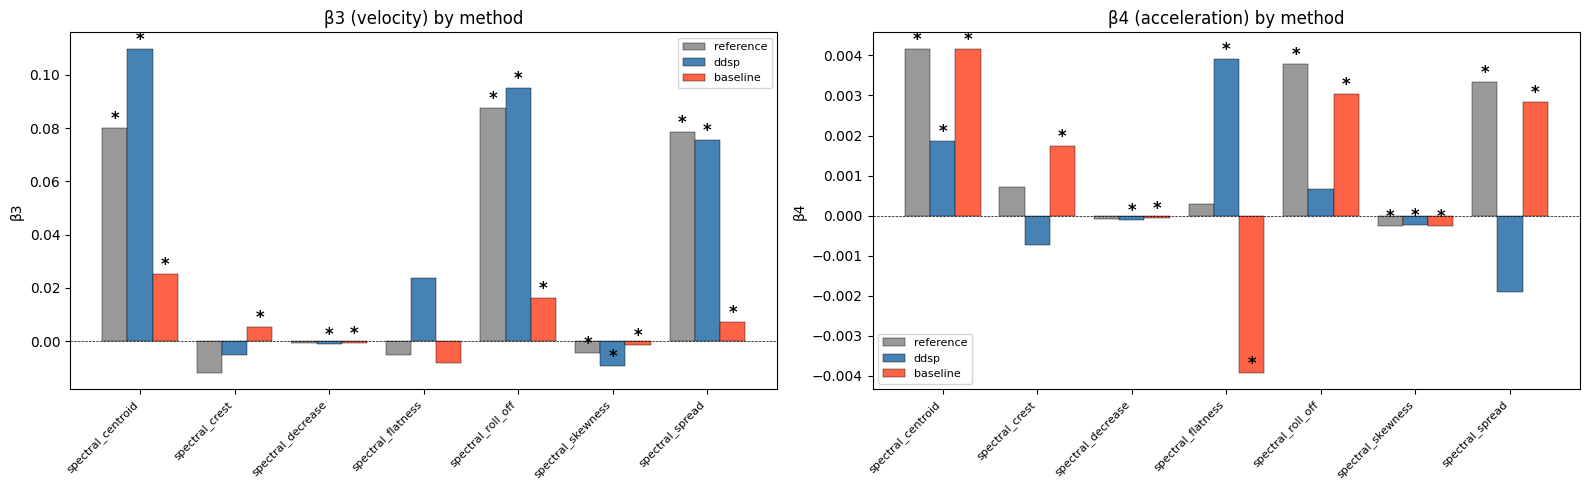

* = significant at p < 0.05


In [31]:
methods = list(all_models.keys())
n_methods = len(methods)
x = np.arange(len(DESCRIPTORS))
width = 0.8 / n_methods

colors = {"reference": "0.6", "ddsp": "steelblue", "baseline": "tomato"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, pivot, sig, title, ylabel in [
    (axes[0], pivot_b3, sig_b3, "β3 (velocity) by method", "β3"),
    (axes[1], pivot_b4, sig_b4, "β4 (acceleration) by method", "β4"),
]:
    for j, method in enumerate(methods):
        vals = pivot[method].values
        sigs = sig[method].values
        color = colors.get(method, f"C{j}")
        bars = ax.bar(x + j * width - (n_methods - 1) * width / 2, vals, width,
                      label=method, color=color, edgecolor="black", linewidth=0.3)
        for bar, s in zip(bars, sigs):
            if s:
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        "*", ha="center", va="bottom", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(DESCRIPTORS, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / f"exp3_dynamics_coefficients{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"* = significant at p < {SIGNIFICANCE_LEVEL}")

### 4.4 Dynamics-only coefficient distance

||[b3,b4]_output - [b3,b4]_ref||:


method,baseline,ddsp
descriptor,,
spectral_centroid,0.054911,0.029891
spectral_crest,0.017205,0.006818
spectral_decrease,0.000311,0.000086
spectral_flatness,0.005167,0.028959
spectral_roll_off,0.071588,0.008022
spectral_skewness,0.003021,0.005141
spectral_spread,0.071418,0.006055


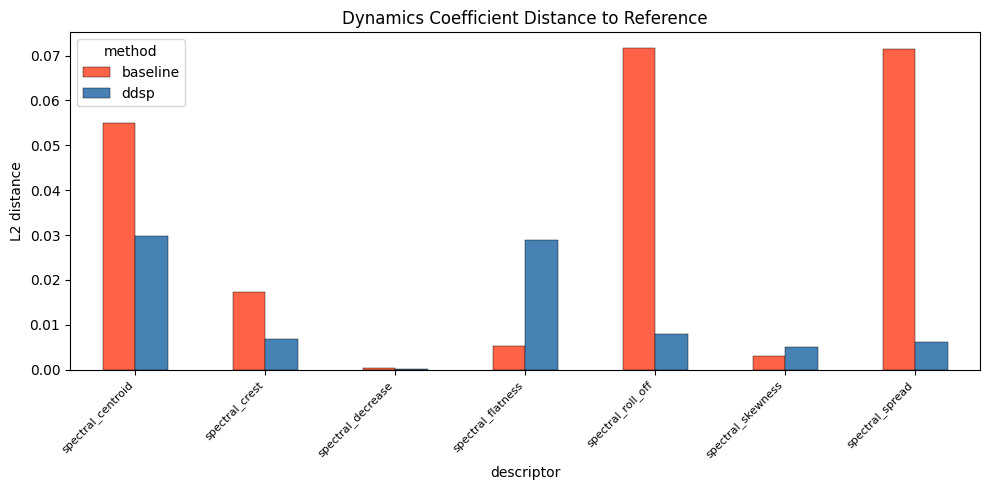

In [32]:
dyn_dist_rows = []
for method in methods:
    if method == "reference":
        continue
    for desc in DESCRIPTORS:
        b_ref = ref_models[desc]["coeffs"][2:4]
        b_out = all_models[method][desc]["coeffs"][2:4]
        dyn_dist_rows.append({
            "method": method,
            "descriptor": desc,
            "dynamics_distance": float(np.linalg.norm(b_out - b_ref)),
        })

df_dyn_dist = pd.DataFrame(dyn_dist_rows)
pivot_dd = df_dyn_dist.pivot(index="descriptor", columns="method", values="dynamics_distance")

print("||[b3,b4]_output - [b3,b4]_ref||:")
display(pivot_dd.round(6))

fig, ax = plt.subplots(figsize=(10, 5))
pivot_dd.plot.bar(ax=ax, color=[colors.get(c, "C0") for c in pivot_dd.columns],
                  edgecolor="black", linewidth=0.3)
ax.set_ylabel("L2 distance")
ax.set_title("Dynamics Coefficient Distance to Reference")
ax.set_xticklabels(DESCRIPTORS, rotation=45, ha="right", fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / f"exp3_dynamics_distance{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.5 Summary

In [33]:
sig_counts = df_dyn.groupby("method")[["b3_significant", "b4_significant"]].sum()
sig_counts.columns = ["n_significant_b3", "n_significant_b4"]
sig_counts["total_descriptors"] = len(DESCRIPTORS)
print("Significant dynamics coefficients per method:")
display(sig_counts)

if not df_dyn_dist.empty:
    mean_dd = df_dyn_dist.groupby("method")["dynamics_distance"].mean()
    print("\nMean dynamics distance to reference:")
    display(mean_dd.round(6))

Significant dynamics coefficients per method:


,n_significant_b3,n_significant_b4,total_descriptors
method,,,
baseline,6,7,7
ddsp,5,4,7
reference,4,4,7



Mean dynamics distance to reference:


method
baseline    0.031946
ddsp        0.012139
Name: dynamics_distance, dtype: float64

## 5. Save results

In [34]:
# Section 2 — reference models  (ref_corr now contains BOTH pearson and spearman keys)
with open(OUT_DIR / f"exp1_ref_coupling_models{SUFFIX}.pkl", "wb") as fh:
    pickle.dump({
        "models": ref_models,
        "descriptors": DESCRIPTORS,
        "config": {
            "sr": SR,
            "frame_width": FRAME_WIDTH,
            "overlap": OVERLAP,
            "confidence_threshold": CONFIDENCE_THRESHOLD,
            "median_window": MEDIAN_WINDOW,
            "dt": dt,
            "pitch_transform": PITCH_TRANSFORM,
        },
        "correlation": ref_corr,
    }, fh)
# df_ref_results.to_csv(OUT_DIR / f"exp1_ref_coupling_results{SUFFIX}.csv")

# Section 3 — method reproduction
df_ce.to_csv(OUT_DIR / f"exp2_coupling_error{SUFFIX}.csv")
df_cd.to_csv(OUT_DIR / f"exp2_coefficient_distance{SUFFIX}.csv")
# Pearson keeps the historical filename; Spearman is saved alongside.
df_corr_pearson.to_csv(OUT_DIR / f"exp2_correlation_summary{SUFFIX}.csv")
df_corr_spearman.to_csv(OUT_DIR / f"exp2_correlation_summary{SUFFIX}_spearman.csv")
with open(OUT_DIR / f"exp2_method_models{SUFFIX}.pkl", "wb") as fh:
    pickle.dump(method_models, fh)

# Section 4 — dynamics
df_dyn.to_csv(OUT_DIR / f"exp3_dynamics_coefficients{SUFFIX}.csv", index=False)
if not df_dyn_dist.empty:
    df_dyn_dist.to_csv(OUT_DIR / f"exp3_dynamics_distance{SUFFIX}.csv", index=False)

print(f"All artifacts saved to {OUT_DIR} with suffix {SUFFIX!r}")

All artifacts saved to /m/home/home3/37/thieun1/unix/Project/final_project/artifacts/evaluation with suffix '_log2'
